# The purpose of this notebook is to take output TDI data, compute the datastream for the TDI-E channel, whiten and normalise it, split it into labelled training, validation and test data and train a CNN on it.

## _Imports and path definitions:_

In [120]:
#IMPORTS
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import os
import h5py
import numpy as np
import tensorflow as tf
from gwpy.timeseries import TimeSeriesDict
from gwpy.timeseries import TimeSeries
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from scipy.signal import windows
from scipy import stats
from sklearn import metrics
import scipy.ndimage as ndi
from librosa import cqt


PATH_src = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
PATH_bethLISA = os.path.abspath(os.path.join(PATH_src, os.pardir))
PATH_glitch_config = os.path.join(PATH_bethLISA, "dist/glitch_config/")
PATH_glitch_data = os.path.join(PATH_bethLISA, "dist/glitch_data/")
PATH_simulation_data = os.path.join(PATH_bethLISA, "dist/simulation_data/")
PATH_tdi_data = os.path.join(PATH_bethLISA, "dist/tdi_data/")
PATH_orbit_data = os.path.join(PATH_bethLISA, "dist/orbit_data/")
PATH_interferometer_plots = os.path.join(PATH_bethLISA,
                                         "dist/interferometer_plots/")

tdi_path = os.path.join(PATH_tdi_data, "default_tdi_output.h5")

## _Compute TDI-E data, whiten and normalise:_

TDI-E timeseries:  [-0.14058931 -0.14058931 -0.14058931 ... -0.14058849 -0.14058922
 -0.14058931]
Number of samples in timeseries:  4147200


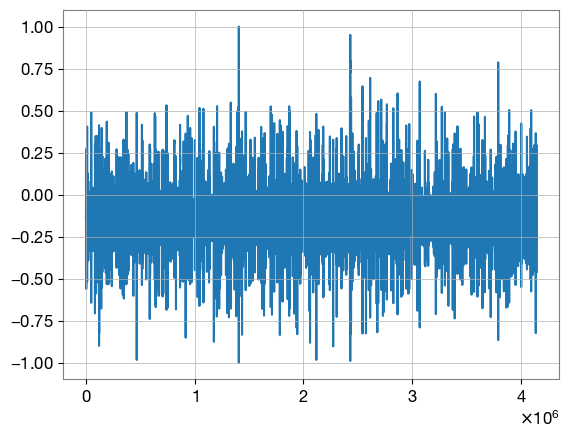

In [121]:
#READ TDI DATA, WHITEN, NORMALISE
tdi_path = os.path.join(PATH_tdi_data, "tdi12d60gpd.h5")

tdiseries = h5py.File(tdi_path,'r')

def whiten(timeseries, eps=1e-8): #WHITEN THE TIMESERIES FROM SCRATCH
    timeseries = timeseries - np.mean(timeseries)
    fftseries = np.fft.fft(timeseries)
    magnitude = np.abs(fftseries)
    whitened_fft = fftseries / (magnitude + eps)
    whitened_timeseries = np.fft.ifft(whitened_fft).real
    return whitened_timeseries


def normalise(timeseries): #NORMALISE THE TIMESERIES USING MODIFIED MIN-MAX NORMALISATION. RESCALED TO [-1,1]
    return 2*((timeseries-np.min(timeseries))/(np.max(timeseries)-np.min(timeseries))) - 1

def minmaxnormalise(timeseries): #NORMALISE THE TIMESERIES USING MIN-MAX NORMALISATION. RESCALED TO [0,1]
    return ((timeseries-np.min(timeseries))/(np.max(timeseries)-np.min(timeseries)))

def moving_average(timeseries, kernelsize):
    return ndi.uniform_filter1d(timeseries, kernelsize, mode='constant', origin=-(kernelsize//2))[:-(kernelsize-1)]


tdiXarray = np.array(tdiseries["X"][:])
tdiYarray = np.array(tdiseries["Y"][:])
tdiZarray = np.array(tdiseries["Z"][:])

tdiE = (1/np.sqrt(6))*(tdiXarray-2*tdiYarray+tdiZarray)

tdiE = normalise(tdiE)
# tdiE = minmaxnormalise(tdiE)
# tdiE = whiten(tdiE)
# tdiE = moving_average(tdiE, 20)




print('TDI-E timeseries: ', tdiE)
print('Number of samples in timeseries: ', len(tdiE))   
plt.plot(tdiE)


## _Get sorted list of injection times:_

In [122]:
#GET FILE PATH OF INJECTED GLITCH PARAMETERS FILE
glitch_output_path = os.path.join(PATH_glitch_data, 'glitch12d60gpd.txt')

#GET THE INJECTION TIMES IN A LIST, ORDERED AND IN UNITS OF SAMPLES
f = open(glitch_output_path, 'r')
glitch_output = f.readlines()[1:]

injection_times = []
for line in glitch_output:
    injection_times.append(4*(int(line.split(' ')[11])-10368000))

f.close()

injection_times = sorted(injection_times)
print('Injection times (in samples): ', injection_times)
print('Number of glitches: ', len(injection_times))



Injection times (in samples):  [2932, 10944, 14880, 21644, 26200, 42984, 48548, 63848, 78732, 82876, 89380, 92944, 101644, 104928, 109148, 111540, 120432, 135596, 138116, 140312, 144936, 151364, 157632, 165188, 171880, 179128, 182732, 191412, 194932, 198396, 201064, 207792, 223112, 230064, 235680, 238260, 246732, 248820, 252528, 261296, 265432, 267776, 277588, 281692, 296072, 301072, 304020, 313828, 317844, 322004, 324772, 327768, 334716, 338524, 345384, 348136, 354424, 359488, 363332, 368124, 372376, 378516, 385168, 390072, 407992, 412348, 419152, 426048, 431952, 435800, 439152, 446632, 454116, 462544, 467044, 479436, 483352, 487008, 490892, 494744, 499176, 503808, 506368, 510000, 514920, 519080, 524812, 529064, 531508, 538056, 541132, 549904, 554848, 558996, 562624, 572784, 574952, 586396, 590008, 594040, 601360, 604920, 615376, 618000, 626040, 629168, 632916, 637016, 642380, 648104, 650664, 658688, 666764, 668776, 674552, 685012, 687688, 699088, 705164, 711456, 715548, 720532, 74049

## _Split timeseries into labelled training, validation and test data in the ratio 5:4:1 :_

In [123]:
#GENERALIZED CONSTANTS
sampling_rate = 4 
window_duration_sec = 600
window_size = window_duration_sec * sampling_rate
total_samples = len(tdiE)
num_windows = total_samples // window_size 

# RESHAPE TIMESERIES INTO MATRIX WITH 10 MINUTE SNIPPETS ON EVERY ROW
data = tdiE[:num_windows * window_size].reshape(num_windows, window_size, 1)

injection_times = np.array(injection_times)

#COUNT NUMBER OF INJECTIONS PER ROW
labels = np.zeros(num_windows, dtype=np.int32)

for i in range(num_windows):
    start = i * window_size
    end = (i + 1) * window_size
    labels[i] = np.sum((injection_times >= (start-340)) & (injection_times < (end))) 
    #count injections between start and end of window including 400 samples into the previous window 
    


# SHUFFLE THE TIMESERIES AROUND
indices = np.arange(num_windows)
np.random.shuffle(indices)

data = data[indices]
labels = labels[indices]

# SPLIT THE DATA INTO THE DIFFERENT SETS
train_size = int(0.6 * num_windows)
val_size = int(0.2 * num_windows)

train_data = data[:train_size]
train_labels = labels[:train_size]

validation_data = data[train_size:train_size + val_size]
validation_labels = labels[train_size:train_size + val_size]

test_data = data[train_size + val_size:]
test_labels = labels[train_size + val_size:]

# #OPTIONAL - LENGTHEN TEST DATA
# test_data = test_data.reshape(num_windows/3, window_size*3, 1)
# test_labels = 
print(test_labels)
print(train_data)


print('Timeseries duration (minutes): ', window_duration_sec/60)
print('Total number of timeseries: ', num_windows)
print('Number of items in training dataset: ', len(train_data))
print('Number of items in validation dataset: ', len(validation_data))
print('Number of items in test dataset: ', len(test_data))


[1 1 0 ... 1 1 0]
[[[-0.18004557]
  [-0.10339205]
  [-0.1674786 ]
  ...
  [-0.11819056]
  [-0.16148659]
  [-0.12932175]]

 [[-0.18273671]
  [-0.06779773]
  [-0.23267285]
  ...
  [-0.16354893]
  [-0.1091642 ]
  [-0.17791099]]

 [[-0.09876672]
  [-0.17280685]
  [-0.12235506]
  ...
  [-0.17385392]
  [-0.10065654]
  [-0.18205853]]

 ...

 [[-0.14168243]
  [-0.14158158]
  [-0.13769445]
  ...
  [-0.15493655]
  [-0.11395682]
  [-0.17693194]]

 [[-0.3822549 ]
  [-0.25388438]
  [-0.36104906]
  ...
  [-0.19077746]
  [-0.10218642]
  [-0.16589686]]

 [[-0.13307768]
  [-0.15167646]
  [-0.12627009]
  ...
  [-0.09241272]
  [-0.18387065]
  [-0.10511619]]]
Timeseries duration (minutes):  10.0
Total number of timeseries:  1728
Number of items in training dataset:  1036
Number of items in validation dataset:  345
Number of items in test dataset:  347


# _Create architecture and train:_ 

In [124]:
model = models.Sequential([
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(2400, 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.GlobalMaxPool1D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

model.summary()

model.fit(train_data, train_labels, validation_data=(validation_data, validation_labels), epochs=30, batch_size=16)

/opt/anaconda3/envs/CanaLISA/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_54 (Conv1D)              │ (None, 2398, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_55 (Conv1D)              │ (None, 2396, 32)       │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 1198, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_56 (Conv1D)              │ (None, 1196, 64)       │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_57 (Conv1D)              │ (None, 1194, 64)       │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 597, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_58 (Conv1D)              │ (None, 595, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_59 (Conv1D)              │ (None, 593, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_9          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,929 (222.38 KB)

 Trainable params: 56,929 (222.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6638 - loss: 0.2878 - val_accuracy: 0.8261 - val_loss: 0.1404
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8315 - loss: 0.1433 - val_accuracy: 0.9420 - val_loss: 0.0577
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9402 - loss: 0.0638 - val_accuracy: 0.9594 - val_loss: 0.0407
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9648 - loss: 0.0423 - val_accuracy: 0.9536 - val_loss: 0.0423
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9489 - loss: 0.0593 - val_accuracy: 0.9536 - val_loss: 0.0379
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9677 - loss: 0.0354 - val_accuracy: 0.9623 - val_loss: 0.0284
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9647 - loss: 0.0426 - val_accuracy: 0.9623 - val_loss: 0.0323
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9752 - loss: 0.0243 - val_accuracy: 0.9594 - v

# _Test accuracy on test data:_

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9853 - loss: 0.0135
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
341 correct predictions out of 347
Model accuracy: 0.983
Accuracy (double check): 98.3%
Number of zeroes in test data: 176
Number of ones in test data: 171
Wrong predictions (location : false negative / positive)  {34: 'FP', 96: 'FN', 211: 'FN', 217: 'FN', 229: 'FN', 279: 'FN'}
False positive rate : 0.0057%
False negative rate: 0.029240%


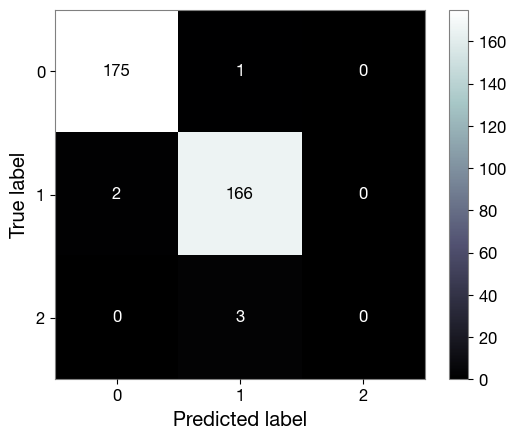

In [127]:
#GET LOSS AND ACCURACY OF MODEL
loss, accuracy = model.evaluate(test_data, test_labels)

#GET PREDICTIONS IN A LIST 
result = model.predict(test_data)
count_correct = 0
count_FP = 0
count_FN = 0
wrong = {}

#FIND CORRECT PREDICTIONS, FALSE POSITIVES AND NEGATIVES
for i in range(len(test_data)):
    if round(result[i][0]) == test_labels[i]:
        count_correct += 1
    elif round(result[i][0]) > test_labels[i]:
        wrong.update({i : 'FP'})
        count_FP += 1
    else:
        wrong.update({i : 'FN'})
        count_FN += 1


print(count_correct, 'correct predictions out of', len(test_data))

acc = count_correct/len(test_data)*100
acc_FN = count_FN/np.count_nonzero(test_labels)
acc_FP = count_FP/(len(test_labels)-np.count_nonzero(test_labels))
acc_TN = 1-acc_FN
acc_TP = 1-acc_FP


print(f'Model accuracy: {accuracy:.3f}')
print(f'Accuracy (double check): {acc:.1f}%')
# print('Test data correct labels: ', test_labels)
print(f'Number of zeroes in test data: {len(test_labels) - np.count_nonzero(test_labels)}')
print(f'Number of ones in test data: {np.count_nonzero(test_labels)}')
# print('Predicted labels: ', result)

print('Wrong predictions (location : false negative / positive) ', wrong)
print(f'False positive rate : {acc_FP:.4f}%')
print(f'False negative rate: {acc_FN:2f}%')



#PLOT CONFUSION MATRIX
cm = metrics.confusion_matrix(test_labels, np.round(result))
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='bone')
plt.grid(False)
plt.show()


0
1
1


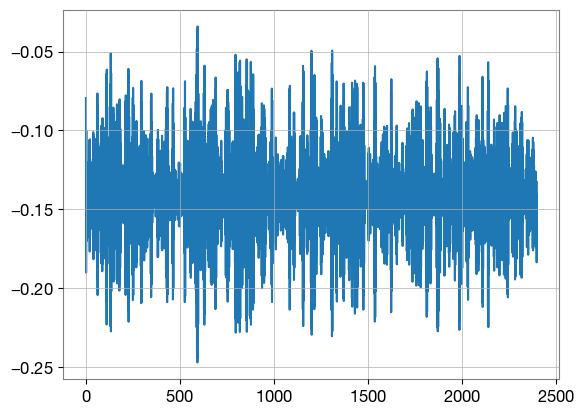

In [132]:
ts_of_interest = 229
print(test_labels[ts_of_interest - 1])
print(test_labels[ts_of_interest])
print(test_labels[ts_of_interest + 1])
# qspec = cqt(ts_of_interest,sr=4, fmin=0.05, n_bins=40)

# plt.imshow(abs(qspec),aspect='auto', origin='lower')
plt.plot(test_data[ts_of_interest])
